# Autoencoder y Variational Autoencoder (VAE) en MNIST

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana04_VAE.ipynb)

En esta notebook construimos primero un **autoencoder (AE)** y luego dos variantes de **Variational Autoencoder (VAE)** usando **PyTorch** sobre **MNIST**.

## Idea general

Un autoencoder aprende dos mapas:

- **Encoder**: lleva una imagen `x` a una representación latente `z`.
- **Decoder**: intenta reconstruir la imagen original a partir de `z`.

La diferencia central entre ambos modelos es:

- En un **AE**, el espacio latente es **determinista**.
- En un **VAE**, el encoder produce una **distribución** sobre el espacio latente y el modelo se entrena para que ese espacio sea estructurado y muestreable.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

## Carga de datos

MNIST contiene imágenes de dígitos manuscritos de tamaño `28 x 28`. Las normalizamos al intervalo `[0, 1]`.

Para que la notebook siga siendo relativamente rápida, usamos un subconjunto moderado del dataset.


In [3]:
transform = transforms.ToTensor()

trainset = datasets.MNIST(
    root='./data',      # A donde se guardan los datos
    train=True,         # Si queremos la partición de entrenamiento o evaluación
    download=True,      # descarga de datos si no ya presente
    transform=transform # transformaciones a los datos
)

test_dataset = datasets.MNIST(
    root="./data", 
    train=False,
    download=True,
    transform=transform)


In [4]:
train_subset = Subset(trainset, range(20000))
test_subset = Subset(test_dataset, range(4000))

batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 157
Test batches: 32


Veamos algunas imágenes y sus etiquetas

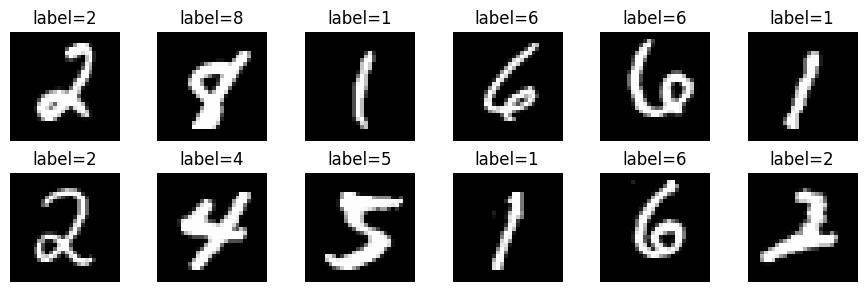

In [7]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 6, figsize=(9, 3))
for ax, img, label in zip(axes.flat, images[:12], labels[:12]):
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(f"label={label.item()}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Autoencoder clásico

Un AE busca aprender una representación comprimida $z = h_\phi(x)$ y una reconstrucción $\hat{x} = f_\theta(z)$ minimizando un error de reconstrucción.

En forma simple:

$$
z = h_\phi(x), \qquad \hat{x} = f_\theta(z)
$$

y se entrena con una pérdida del tipo

$$
\mathcal{L}_{AE}(x, \hat{x}) = \text{Recon}(x, \hat{x})
$$

El Autoencoder aprende una compresión útil para reconstruir los datos, es decir, una representación latente que suele ser de menor dimensionalidad, en donde se intentan separa patrones relevantes.  Aunque el AE reconstruya bien, **no obliga** a que los puntos del espacio latente sigan una distribución simple. Por eso, si tomamos un `z` aleatorio, el decoder puede producir una resultado sin el sentido esperado. Esa es una de las razones para pasar a un VAE.

En esta notebook usamos una reconstrucción basada en **binary cross-entropy** porque los píxeles de MNIST están en `[0,1]` y el decoder puede interpretarse como una probabilidad por píxel.


In [64]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
        )

    def forward(self, x):
        z = self.encoder(x)
        logits = self.decoder(z)
        return logits.view(-1, 1, 28, 28), z


def ae_loss(x_logits, x):
    return nn.functional.binary_cross_entropy_with_logits(x_logits, x, reduction="sum") / x.size(0)

In [75]:
@torch.no_grad()
def show_reconstructions(model, loader, n=8, title="Reconstrucciones"):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(DEVICE)
    logits, _ = model(x)
    x_hat = torch.sigmoid(logits)
    # x_hat = (x_hat > 0.5).float()
    # x = (x.cpu() > 0.5).float()

    fig, axes = plt.subplots(2, n, figsize=(1.6 * n, 3.2))
    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i, 0].cpu(), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("original", fontsize=11)
    axes[1, 0].set_ylabel("recon", fontsize=11)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def train_epoch_ae(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for x, _ in loader:
        x = x.to(DEVICE)
        logits, _ = model(x)
        loss = ae_loss(logits, x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


In [66]:
ae = Autoencoder(latent_dim=2).to(DEVICE)
ae_optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)


In [67]:
ae_history = []
ae_epochs = 100

ae_test_history = []
for epoch in range(1, ae_epochs + 1):
    loss = train_epoch_ae(ae, train_loader, ae_optimizer)
    ae_history.append(loss)
    
    with torch.no_grad():
        ae.eval()
        loss_test = 0.0
        for x, _ in test_loader:
            x = x.to(DEVICE)
            logits, _ = ae(x)
            loss = ae_loss(logits, x)
            loss_test += loss.item() * x.size(0)
        loss_test /= len(test_loader.dataset)
            
    ae_test_history.append(loss_test)
    if epoch%10 == 0:
        print(f"AE | epoch {epoch:02d} | loss = {loss:.4f} | test_loss = {loss_test:.4f}")


AE | epoch 10 | loss = 130.9634 | test_loss = 146.5974
AE | epoch 20 | loss = 127.3412 | test_loss = 142.4212
AE | epoch 30 | loss = 125.5546 | test_loss = 140.6660
AE | epoch 40 | loss = 124.3302 | test_loss = 139.5688
AE | epoch 50 | loss = 123.1937 | test_loss = 138.2811
AE | epoch 60 | loss = 123.5801 | test_loss = 138.2701
AE | epoch 70 | loss = 124.0624 | test_loss = 137.9626
AE | epoch 80 | loss = 129.4604 | test_loss = 138.2132
AE | epoch 90 | loss = 123.6594 | test_loss = 138.0142
AE | epoch 100 | loss = 126.7145 | test_loss = 138.6860


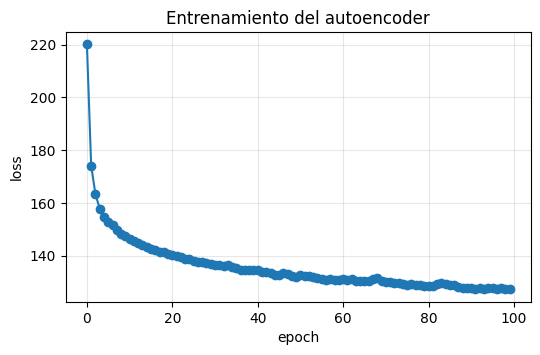

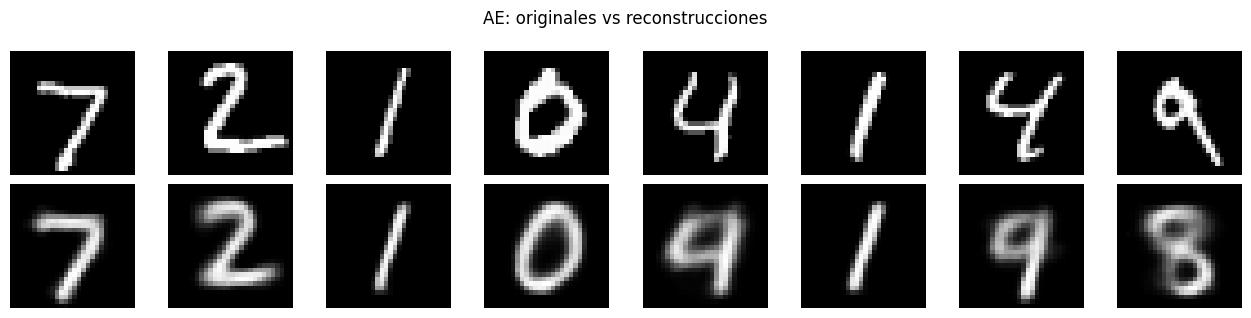

In [76]:
plt.figure(figsize=(6, 3.5))
plt.plot(ae_history, marker="o")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Entrenamiento del autoencoder")
plt.grid(alpha=0.3)
plt.show()

show_reconstructions(ae, test_loader, title="AE: originales vs reconstrucciones")


## Interpolacion en el espacio latente

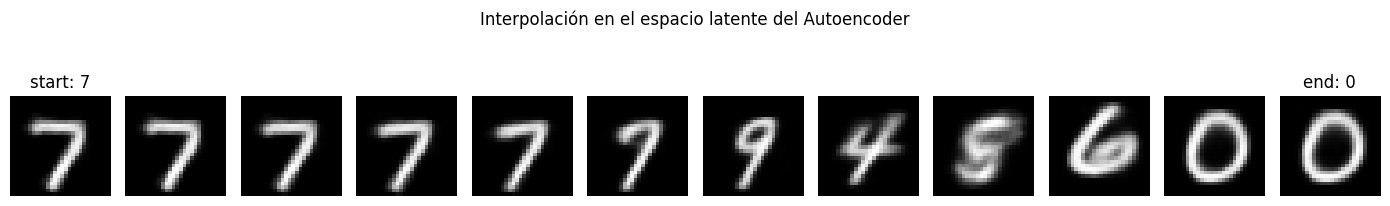

In [94]:
@torch.no_grad()
def interpolate_ae(model, x_start, x_end, steps=10):
    model.eval()
    x_start = x_start.unsqueeze(0).to(DEVICE)
    x_end = x_end.unsqueeze(0).to(DEVICE)

    z_start = model.encoder(x_start)
    z_end = model.encoder(x_end)

    alphas = torch.linspace(0.0, 1.0, steps, device=DEVICE).view(-1, 1)
    z_interp = z_start * (1 - alphas) + z_end * alphas

    logits = model.decoder(z_interp)
    return torch.sigmoid(logits).cpu()


x_batch, y_batch = next(iter(test_loader))

idx_start, idx_end = 0, 10
x_start = x_batch[idx_start]
x_end = x_batch[idx_end]

interp_images = interpolate_ae(ae, x_start, x_end, steps=10)

fig, axes = plt.subplots(1, interp_images.size(0) + 2, figsize=(14, 2.5))

axes[0].imshow(torch.sigmoid(ae(x_start)[0]).view(28,28).detach().numpy(), cmap="gray")
axes[0].set_title(f"start: {y_batch[idx_start].item()}")
axes[0].axis("off")

for i, img in enumerate(interp_images):
    axes[i + 1].imshow(img.view(28, 28), cmap="gray")
    axes[i + 1].axis("off")

axes[-1].imshow(torch.sigmoid(ae(x_end)[0]).view(28,28).detach().numpy(), cmap="gray")
axes[-1].set_title(f"end: {y_batch[idx_end].item()}")
axes[-1].axis("off")

fig.suptitle("Interpolación en el espacio latente del Autoencoder")
plt.tight_layout()
plt.show()

## Del AE al VAE

El problema del AE es que el espacio latente no está regularizado. Un VAE corrige esto haciendo que el encoder ya no produzca un único vector, sino los parámetros de una distribución gaussiana:

$$
q_\phi(z \mid x) = \mathcal{N}(z; \mu(x), \operatorname{diag}(\sigma^2(x)))
$$

Entonces, para cada imagen $x$, el encoder produce:

- una media $\mu(x)$
- una varianza (o $\log \sigma^2(x)$ para mayor estabilidad numérica)

Luego se toma una muestra latente con el truco de **reparametrización**:

$$
z = \mu + \sigma \odot \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)
$$

Esto permite que el muestreo siga siendo diferenciable respecto de los parámetros del encoder.

## Función de costo del VAE

El VAE se entrena maximizando una cota inferior de la verosimilitud, conocida como **ELBO**. En práctica, esto equivale a minimizar:

$$
\mathcal{L}_{VAE} = \underbrace{\mathcal{L}_{rec}}_{\text{reconstrucción}} + \beta \, \underbrace{D_{KL}\left(q_\phi(z\mid x)\;||\;p(z)\right)}_{\text{regularización latente}}
$$

En esta notebook elegimos:

$$
\mathcal{L}_{rec} = \text{BCE}(x, \hat{x})
$$

porque:

- las imágenes están normalizadas entre `0` y `1`;
- el decoder produce **logits** por píxel;
- aplicar `sigmoid` a esos logits da probabilidades por píxel;
- la BCE corresponde a un modelo Bernoulli independiente por píxel, una elección estándar para MNIST.

El término KL, cuando $q_\phi(z|x)$ es gaussiana diagonal y $p(z)=\mathcal{N}(0,I)$, tiene forma cerrada:

$$
D_{KL} = -\frac{1}{2} \sum_j \left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)
$$


In [95]:
class MLPVAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim
        self.feature_extractor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(128, latent_dim)
        self.logvar_head = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
        )

    def encode(self, x):
        h = self.feature_extractor(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h).clamp(-6.0, 2.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        logits = self.decoder(z)
        return logits.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


class CNNVAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.SiLU(),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.SiLU(),
        )
        self.mu_head = nn.Linear(256, latent_dim)
        self.logvar_head = nn.Linear(256, latent_dim)

        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.SiLU(),
            nn.Linear(256, 128 * 4 * 4),
            nn.SiLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.SiLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h).clamp(-6.0, 2.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, 128, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


def vae_loss(x_logits, x, mu, logvar, beta=1.0):
    recon = nn.functional.binary_cross_entropy_with_logits(
        x_logits, x, reduction="sum"
    ) / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total = recon + beta * kl
    return total, recon, kl


### Modificación de pesos en la función de costo durante el aprendizaje

- Si el KL pesa demasiado desde el principio, el modelo puede colapsar a un latente poco informativo y reconstruir mal.
- Si el KL pesa demasiado chico, el modelo reconstruye bien pero el espacio latente queda desordenado.

El **KL warmup** arranca con `\beta` pequeño y lo incrementa gradualmente. En la práctica, esto suele producir:

- mejores reconstrucciones en las primeras épocas;
- un espacio latente más suave y mejor separado al final.

In [96]:
def kl_weight_schedule(epoch, total_epochs, beta_max=2.0, warmup_epochs=12):
    if epoch <= 1:
        return 0.05
    if epoch >= warmup_epochs:
        return beta_max
    progress = (epoch - 1) / max(1, warmup_epochs - 1)
    return 0.05 + progress * (beta_max - 0.05)


def train_epoch_vae(model, loader, optimizer, beta):
    model.train()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    for x, _ in loader:
        x = x.to(DEVICE)
        logits, mu, logvar = model(x)
        loss, recon, kl = vae_loss(logits, x, mu, logvar, beta=beta)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_recon += recon.item() * x.size(0)
        total_kl += kl.item() * x.size(0)

    n = len(loader.dataset)
    return total_loss / n, total_recon / n, total_kl / n


In [97]:
latent_dim = 2

mlp_vae = MLPVAE(latent_dim=latent_dim).to(DEVICE)
cnn_vae = CNNVAE(latent_dim=latent_dim).to(DEVICE)

models = {
    "MLP-VAE": {
        "model": mlp_vae,
        "optimizer": torch.optim.Adam(mlp_vae.parameters(), lr=1e-3),
    },
    "CNN-beta-VAE": {
        "model": cnn_vae,
        "optimizer": torch.optim.Adam(cnn_vae.parameters(), lr=8e-4),
    },
}


In [98]:
histories = {
    name: {"total": [], "recon": [], "kl": [], "beta": []}
    for name in models
}
vae_epochs = 28

for epoch in range(1, vae_epochs + 1):
    beta = kl_weight_schedule(epoch, vae_epochs, beta_max=2.0, warmup_epochs=12)
    for name, bundle in models.items():
        loss, recon, kl = train_epoch_vae(
            bundle["model"],
            train_loader,
            bundle["optimizer"],
            beta=beta,
        )
        histories[name]["total"].append(loss)
        histories[name]["recon"].append(recon)
        histories[name]["kl"].append(kl)
        histories[name]["beta"].append(beta)
        print(
            f"{name} | epoch {epoch:02d} | beta = {beta:.2f} | "
            f"total = {loss:.4f} | recon = {recon:.4f} | kl = {kl:.4f}"
        )
    print()


MLP-VAE | epoch 01 | beta = 0.05 | total = 211.9469 | recon = 211.7264 | kl = 4.4105
CNN-beta-VAE | epoch 01 | beta = 0.05 | total = 235.2712 | recon = 234.8699 | kl = 8.0253

MLP-VAE | epoch 02 | beta = 0.23 | total = 173.1433 | recon = 171.3707 | kl = 7.7994
CNN-beta-VAE | epoch 02 | beta = 0.23 | total = 156.7914 | recon = 154.6772 | kl = 9.3027

MLP-VAE | epoch 03 | beta = 0.40 | total = 166.3789 | recon = 163.5036 | kl = 7.1074
CNN-beta-VAE | epoch 03 | beta = 0.40 | total = 152.8178 | recon = 149.5623 | kl = 8.0475

MLP-VAE | epoch 04 | beta = 0.58 | total = 164.2604 | recon = 160.4777 | kl = 6.5015
CNN-beta-VAE | epoch 04 | beta = 0.58 | total = 150.3173 | recon = 146.0153 | kl = 7.3941

MLP-VAE | epoch 05 | beta = 0.76 | total = 162.3558 | recon = 157.6852 | kl = 6.1528
CNN-beta-VAE | epoch 05 | beta = 0.76 | total = 149.0189 | recon = 143.7256 | kl = 6.9731

MLP-VAE | epoch 06 | beta = 0.94 | total = 161.2481 | recon = 155.7878 | kl = 5.8314
CNN-beta-VAE | epoch 06 | beta = 0.

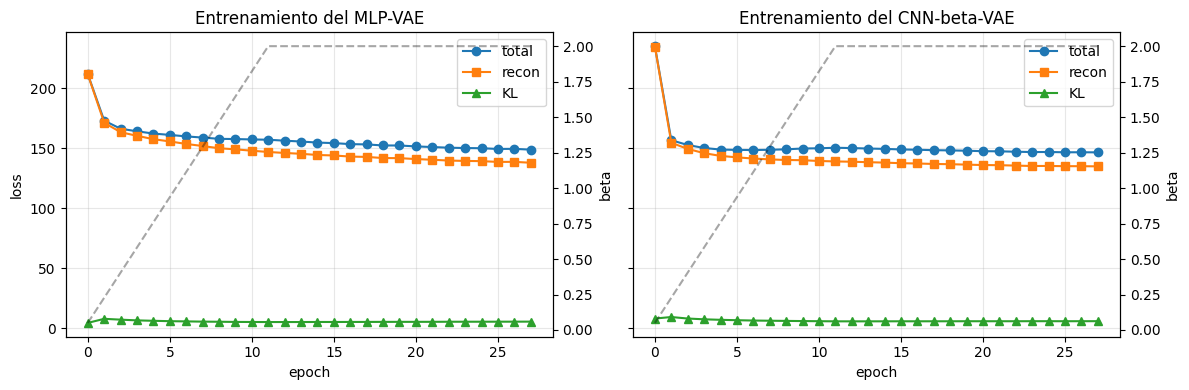

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (name, history) in zip(axes, histories.items()):
    ax.plot(history["total"], marker="o", label="total")
    ax.plot(history["recon"], marker="s", label="recon")
    ax.plot(history["kl"], marker="^", label="KL")
    ax.set_xlabel("epoch")
    ax.set_title(f"Entrenamiento del {name}")
    ax.grid(alpha=0.3)
    ax.legend()

    ax_beta = ax.twinx()
    ax_beta.plot(history["beta"], color="black", linestyle="--", alpha=0.35, label="beta")
    ax_beta.set_ylabel("beta", color="black")
    ax_beta.tick_params(axis="y", colors="black")

axes[0].set_ylabel("loss")
plt.tight_layout()
plt.show()


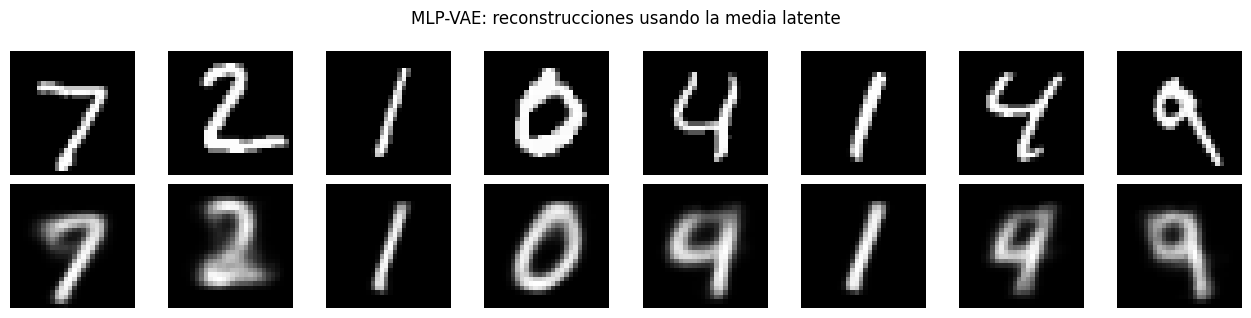

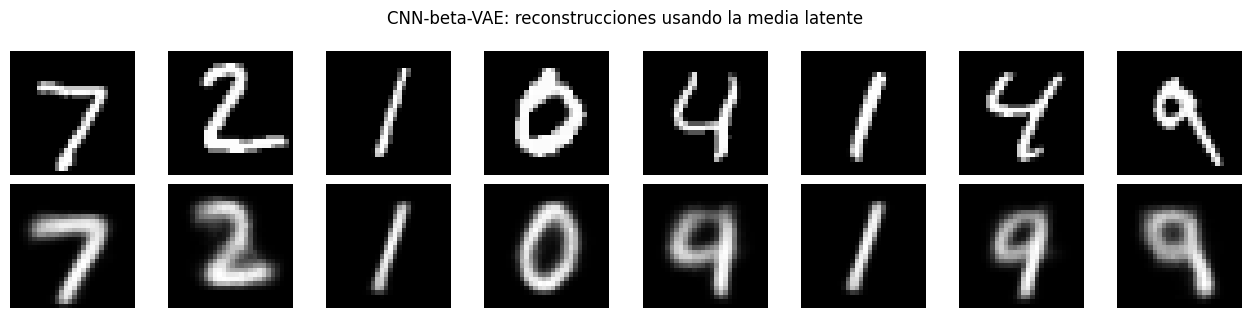

In [101]:
@torch.no_grad()
def show_vae_reconstructions(model, loader, title, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(DEVICE)
    mu, logvar = model.encode(x)
    logits = model.decode(mu)
    x_hat = torch.sigmoid(logits)

    fig, axes = plt.subplots(2, n, figsize=(1.6 * n, 3.2))
    for i in range(n):
        axes[0, i].imshow(x[i, 0].cpu(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i, 0].cpu(), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("original", fontsize=11)
    axes[1, 0].set_ylabel("recon", fontsize=11)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_vae_reconstructions(mlp_vae, test_loader, title="MLP-VAE: reconstrucciones usando la media latente")
show_vae_reconstructions(cnn_vae, test_loader, title="CNN-beta-VAE: reconstrucciones usando la media latente")


## Espacio latente de ambos VAE

Como elegimos un latente bidimensional, podemos visualizar directamente las medias `mu(x)` aprendidas por el encoder.

En esta versión conviene mirar especialmente el **CNN-beta-VAE**:

- la arquitectura convolucional mejora la calidad de las características;
- el `beta` creciente empuja más la organización del latente;
- el warmup evita que esa regularización destruya la reconstrucción al comienzo del entrenamiento.

No esperamos una separación perfecta por clase, porque el modelo sigue siendo no supervisado, pero sí una estructura más suave y regiones más diferenciadas.


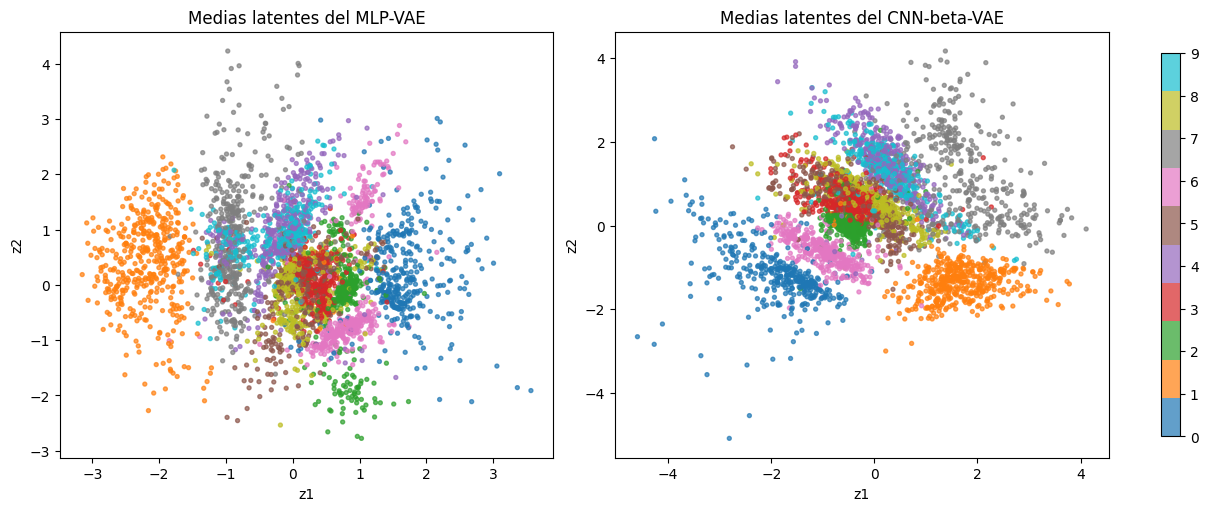

In [102]:
@torch.no_grad()
def collect_latent_means(model, loader):
    model.eval()
    mus = []
    ys = []
    for x, y in loader:
        x = x.to(DEVICE)
        mu, logvar = model.encode(x)
        mus.append(mu.cpu())
        ys.append(y)
    return torch.cat(mus), torch.cat(ys)

latent_results = {
    name: collect_latent_means(bundle["model"], test_loader)
    for name, bundle in models.items()
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
scatter = None

for ax, (name, (latent_mu, latent_y)) in zip(axes, latent_results.items()):
    scatter = ax.scatter(latent_mu[:, 0], latent_mu[:, 1], c=latent_y, cmap="tab10", s=8, alpha=0.7)
    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_title(f"Medias latentes del {name}")

fig.colorbar(scatter, ax=axes.ravel().tolist(), shrink=0.9)
plt.show()


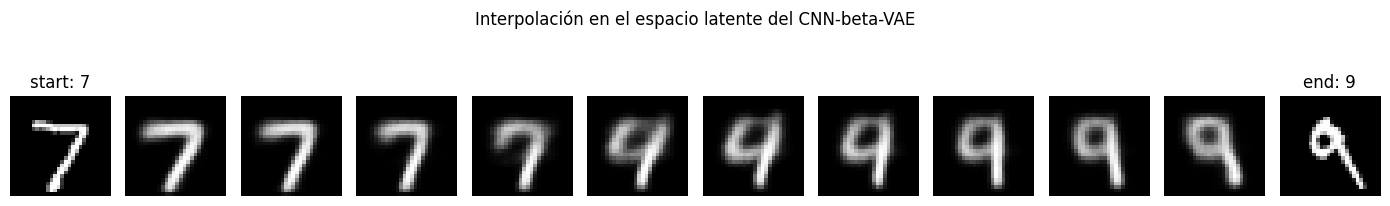

In [104]:
@torch.no_grad()
def interpolate_cnn_vae(model, x_start, x_end, steps=10):
    model.eval()
    x_start = x_start.unsqueeze(0).to(DEVICE)
    x_end = x_end.unsqueeze(0).to(DEVICE)

    mu_start, _ = model.encode(x_start)
    mu_end, _ = model.encode(x_end)

    alphas = torch.linspace(0.0, 1.0, steps, device=DEVICE).view(-1, 1)
    z_interp = mu_start * (1 - alphas) + mu_end * alphas

    logits = model.decode(z_interp)
    return torch.sigmoid(logits).cpu()


x_batch, y_batch = next(iter(test_loader))
idx_start, idx_end = 0, 7
x_start = x_batch[idx_start]
x_end = x_batch[idx_end]

interp_images = interpolate_cnn_vae(cnn_vae, x_start, x_end, steps=10)

fig, axes = plt.subplots(1, interp_images.size(0) + 2, figsize=(14, 2.5))

axes[0].imshow(x_start.squeeze(0), cmap="gray")
axes[0].set_title(f"start: {y_batch[idx_start].item()}")
axes[0].axis("off")

for i, img in enumerate(interp_images):
    axes[i + 1].imshow(img[0], cmap="gray")
    axes[i + 1].axis("off")

axes[-1].imshow(x_end.squeeze(0), cmap="gray")
axes[-1].set_title(f"end: {y_batch[idx_end].item()}")
axes[-1].axis("off")

fig.suptitle("Interpolación en el espacio latente del CNN-beta-VAE")
plt.tight_layout()
plt.show()

## Generación de nuevas muestras

Ahora sí tiene sentido muestrear desde el prior:

$$
z \sim \mathcal{N}(0, I)
$$

Luego decodificamos esos puntos para obtener nuevas imágenes. Esta operación es mucho más natural en un VAE que en un AE clásico, justamente porque el entrenamiento regularizó el espacio latente. Abajo comparamos las muestras del MLP-VAE y del CNN-VAE.


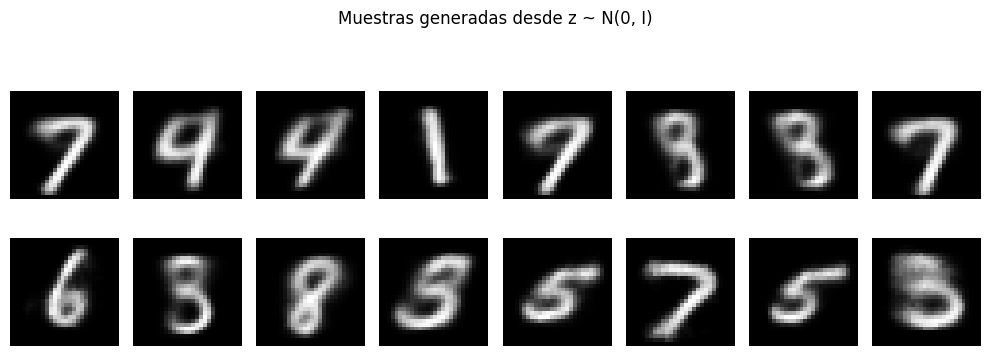

In [105]:
@torch.no_grad()
def sample_from_vae(model, n=16):
    model.eval()
    z = torch.randn(n, model.latent_dim, device=DEVICE)
    logits = model.decode(z)
    return torch.sigmoid(logits).cpu()


fig, axes = plt.subplots(2, 8, figsize=(10, 4))

for row, (name, bundle) in enumerate(models.items()):
    samples = sample_from_vae(bundle["model"], n=8)
    for col, img in enumerate(samples):
        axes[row, col].imshow(img[0], cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(name, fontsize=11)

fig.suptitle("Muestras generadas desde z ~ N(0, I)")
plt.tight_layout()
plt.show()


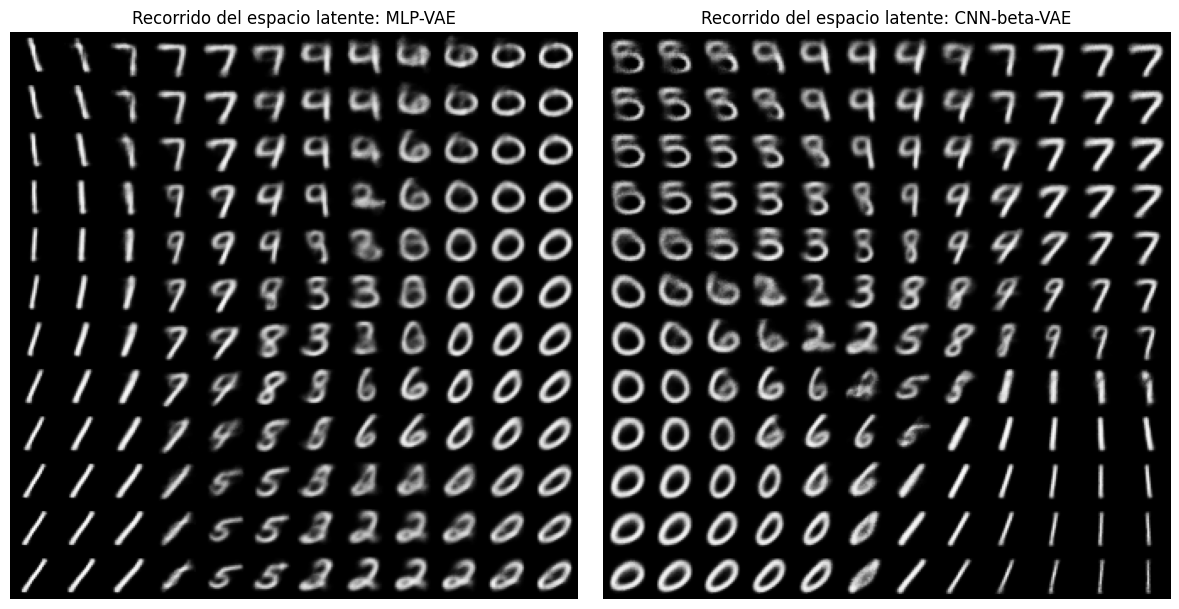

In [106]:
@torch.no_grad()
def latent_grid(model, grid_size=12, span=2.5):
    model.eval()
    coords = torch.linspace(-span, span, grid_size)
    canvas = torch.zeros(28 * grid_size, 28 * grid_size)
    for i, y in enumerate(reversed(coords)):
        for j, x in enumerate(coords):
            z = torch.tensor([[x, y]], dtype=torch.float32, device=DEVICE)
            img = torch.sigmoid(model.decode(z))[0, 0].cpu()
            canvas[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = img
    return canvas


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, (name, bundle) in zip(axes, models.items()):
    ax.imshow(latent_grid(bundle["model"]), cmap="gray")
    ax.set_title(f"Recorrido del espacio latente: {name}")
    ax.axis("off")

plt.tight_layout()
plt.show()
